# 🧠 Project: Brain Tumor MRI Classification

**Dataset Link:** https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri/data

## 📚 About the Dataset

This dataset contains MRI scans categorized into 4 classes:

   **1. Glioma Tumor**

   **2. Meningioma Tumor**

   **3. Pituitary Tumor**

   **4. No Tumor**

The goal is to train a Convolutional Neural Network (CNN) to correctly label a given MRI scan.

# 🛠️ Step 1: Imports & Setup

**cv2 (OpenCV):** Used to read and resize the MRI images.

**keras.models.Sequential:** The easiest way to build a Neural Network (stacking layers one by one).

**sklearn:** Used to shuffle the data and split it into training and testing sets.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

In [5]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score

2025-11-20 16:40:53.386972: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763656853.561784      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763656853.613349      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [18]:
import ipywidgets as widgets
import io
import os
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

# 📥 Step 2: Data Loading & Preprocessing

**Loading:** The code iterates through the folders for each tumor type.

**Resizing:** All images are resized to 150x150 pixels to ensure the neural network gets consistent input.

**Merging:** Interestingly, this notebook seems to combine both the "Training" and "Testing" folders from the original dataset into one big X_train list, and then splits them manually later.

In [21]:
X_train = []
Y_train = []
image_size = 150
labels = ['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']
for i in labels:
    folderPath = os.path.join('/kaggle/input/brain-tumor-classification-mri/Training',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)
        
for i in labels:
    folderPath = os.path.join('/kaggle/input/brain-tumor-classification-mri/Testing',i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

In [22]:
print("Total images:", len(X_train))
print("Image shape:", X_train[0].shape)
print("Unique labels:", np.unique(Y_train))

Total images: 3264
Image shape: (150, 150, 3)
Unique labels: ['glioma_tumor' 'meningioma_tumor' 'no_tumor' 'pituitary_tumor']


In [23]:
df = pd.DataFrame(Y_train, columns=['Tumor_Type'])
print("\nClass Distribution:")
print(df['Tumor_Type'].value_counts())


Class Distribution:
Tumor_Type
meningioma_tumor    937
glioma_tumor        926
pituitary_tumor     901
no_tumor            500
Name: count, dtype: int64


# 📊 Step 3: Visualization

This checks for class imbalance and visualizes the data

  **Bar Chart:** Shows how many images exist for each tumor type.

  **Sample Images:** Displays random MRI scans to verify they were loaded correctly.

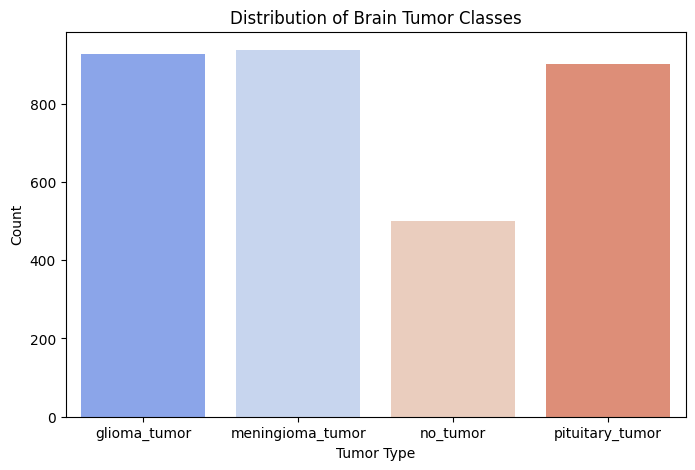

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tumor_Type', data=df, palette='coolwarm')
plt.title('Distribution of Brain Tumor Classes')
plt.xlabel('Tumor Type')
plt.ylabel('Count')
plt.show()

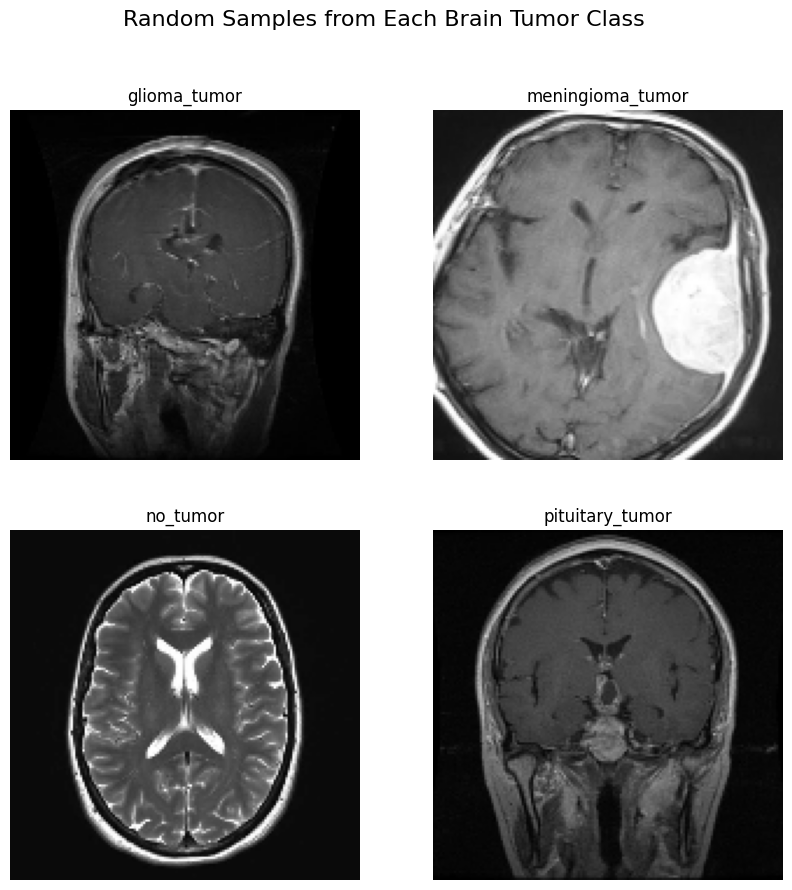

In [25]:
plt.figure(figsize=(10,10))
for i, label in enumerate(labels):
    plt.subplot(2,2,i+1)
    indices = np.where(Y_train == label)[0]
    if len(indices) > 0:
        sample = random.choice(indices)
        plt.imshow(cv2.cvtColor(X_train[sample], cv2.COLOR_BGR2RGB))
        plt.title(label)
        plt.axis('off')
    else:
        plt.text(0.3, 0.5, f"No images for {label}", fontsize=12)
        plt.axis('off')
plt.suptitle("Random Samples from Each Brain Tumor Class", fontsize=16)
plt.show()


In [26]:
X_train,Y_train = shuffle(X_train,Y_train,random_state=101)
X_train.shape


(3264, 150, 150, 3)

## Splitting & Encoding


**train_test_split:** It keeps 90% of data for training and sets aside 10% for testing.

**to_categorical:** Converts text labels (e.g., "glioma") into "One-Hot Encoded" vectors (e.g., [1, 0, 0, 0]).

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X_train,Y_train,test_size=0.1,random_state=101)

In [28]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train=y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test=y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

# 🏗️ Step 4: The CNN Architecture

This is the "Brain" of the project. It uses a custom Deep CNN architecture.

The Architecture

   **1. Input Layer:** Accepts 150x150 RGB images.

   **2. Conv2D Layers:** These act as "feature detectors." They scan the image to find edges, textures, and tumor shapes.

   **3. MaxPooling2D:** Reduces the image size (downsampling) to make processing faster and reduce noise.

   **4. Dropout:** Randomly turns off neurons during training. This prevents the model from "memorizing" the training data (overfitting).

   **5. Dense (Output) Layer:** A final layer with 4 neurons (one for each tumor type) using softmax activation to output probabilities.
   
   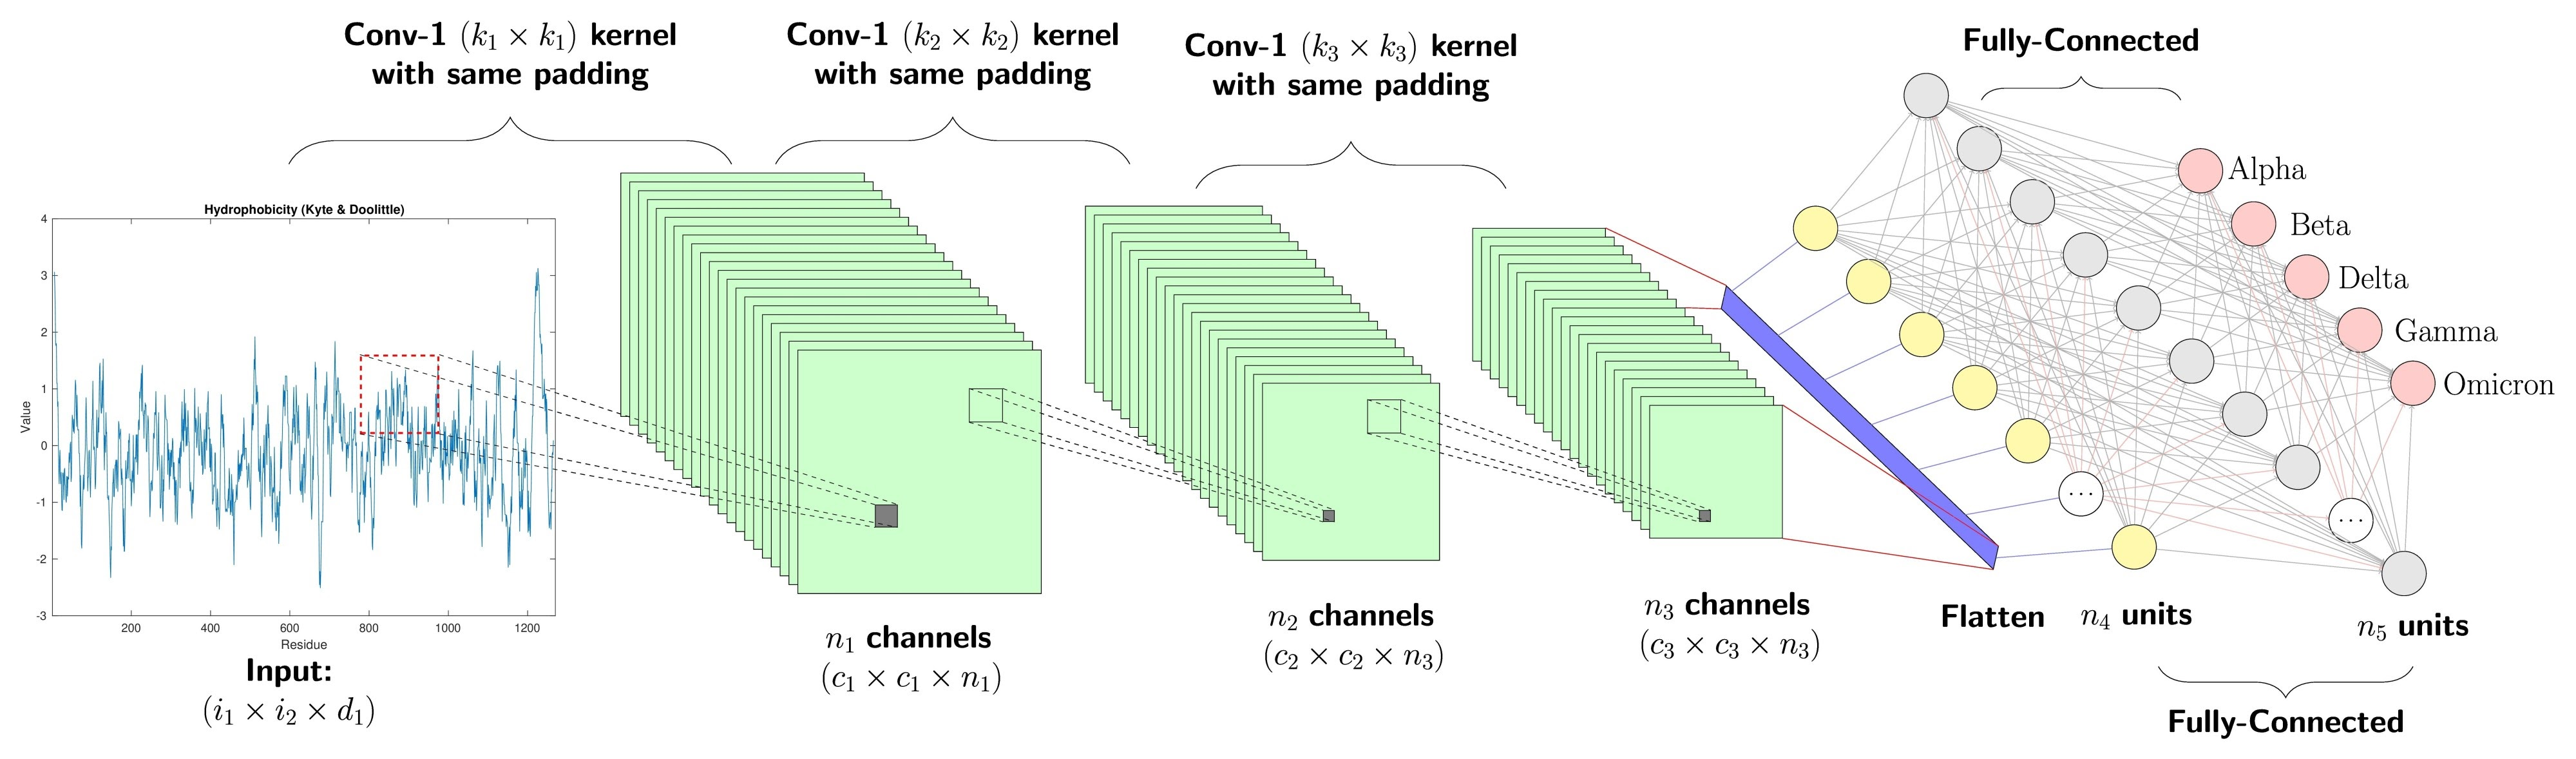

In [64]:
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(150,150,3)))
model.add(Conv2D(64,(3,3),activation='relu', kernel_regularizer=tf.keras.regularizers.L2(l2=0.007)))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.25))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu', kernel_regularizer=tf.keras.regularizers.L2(l2=0.005)))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.35))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu', kernel_regularizer=tf.keras.regularizers.L2(l2=0.003)))
model.add(Flatten())
model.add(Dense(50,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(4,activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 69, 69, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │        25,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           20

 Total params: 4,470,846 (17.05 MB)

 Trainable params: 4,470,846 (17.05 MB)

 Non-trainable params: 0 (0.00 B)

# 🚀 Step 5: Training the Model

**Optimizer (AdamW):** A modern variant of Adam (Adaptive Moment Estimation) that is often better at generalization.

**Loss Function:** categorical_crossentropy is standard for multi-class classification.

**Epochs:** The model sees the data 25 times.

In [66]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.AdamW(),
              metrics=['accuracy'])
history = model.fit(X_train,y_train,epochs=25,validation_split=0.1)

Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.2914 - loss: 3.9417 - val_accuracy: 0.2891 - val_loss: 2.7779
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2918 - loss: 2.6468 - val_accuracy: 0.2891 - val_loss: 2.3532
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.2979 - loss: 2.2650 - val_accuracy: 0.2789 - val_loss: 2.1065
Epoch 4/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3163 - loss: 2.0336 - val_accuracy: 0.3776 - val_loss: 1.8531
Epoch 5/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4442 - loss: 1.7249 - val_accuracy: 0.5102 - val_loss: 1.5174
Epoch 6/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5385 - loss: 1.4592 - val_accuracy: 0.5238 - val_loss: 1.4122
Epoch 7/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6036 - loss: 1.2595 - val_accuracy: 0.6803 - val_loss: 1.0787
Epoch 8/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6433 - loss: 1.1046 - val_accuracy: 0.5714 -

### Output

The graphs (Accuracy and Loss) show the model's progress. You want the Training and Validation lines to move together. If Training goes up but Validation goes down, the model is overfitting.

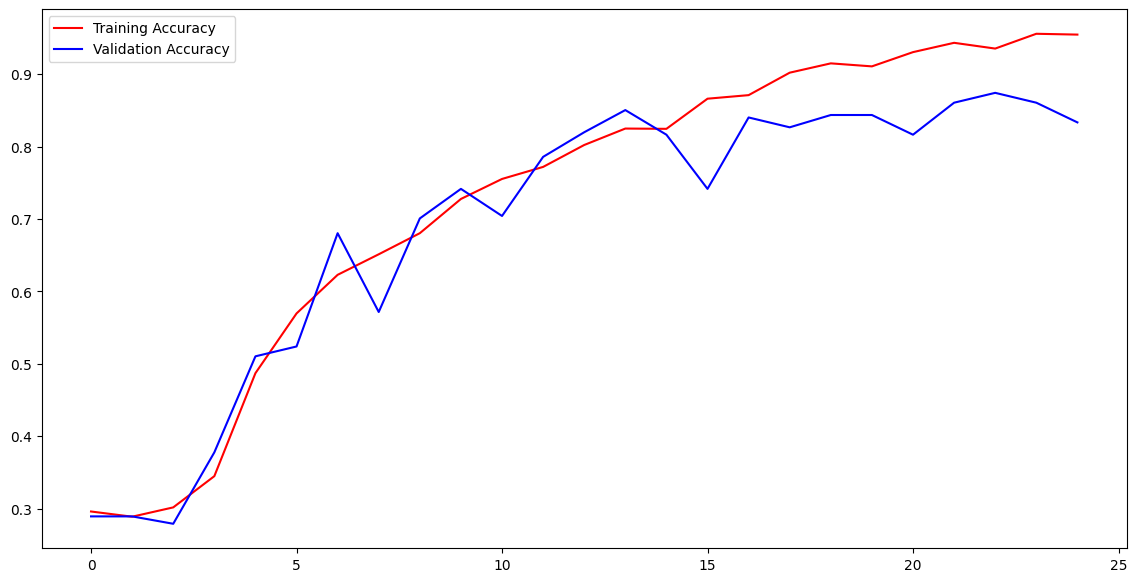

In [67]:
#model.save('braintumor.keras')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()



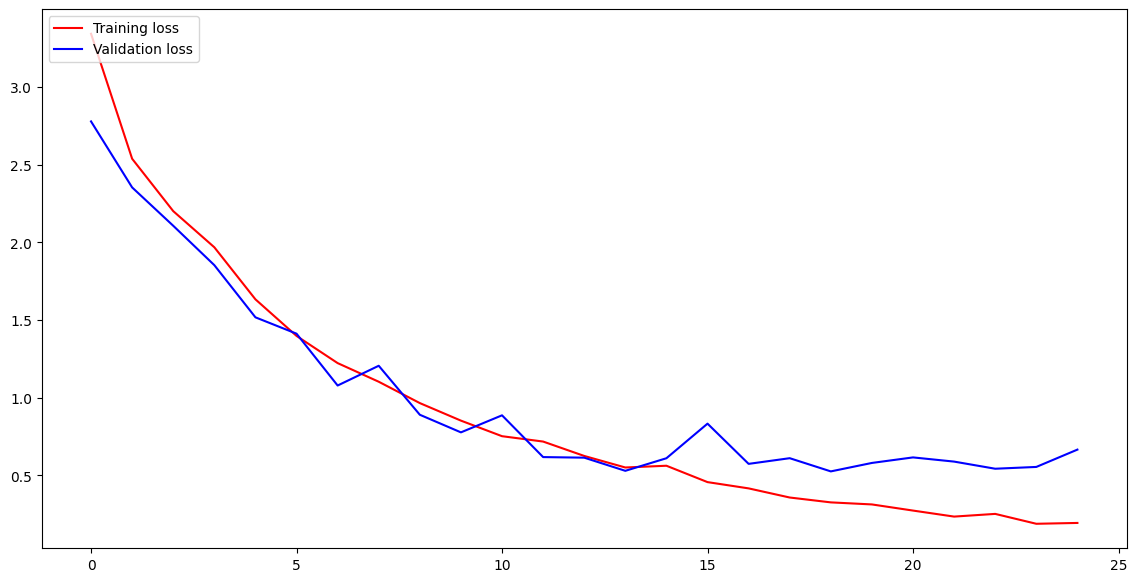

In [68]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

# 📈 Step 6: Evaluation

**Test Accuracy:** The final score on the unseen test set.

**Classification Report:** Breaks down precision and recall for each tumor type. This tells you if the model struggles with a specific tumor (e.g., confusing Glioma with Meningioma).

In [69]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8416 - loss: 0.8022
Test Accuracy: 83.79%
Test Loss: 0.6766


In [70]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [71]:
print(classification_report(y_true, y_pred_classes, target_names=labels))

                  precision    recall  f1-score   support

    glioma_tumor       0.72      0.86      0.78        93
meningioma_tumor       0.84      0.67      0.75        95
        no_tumor       0.90      0.85      0.87        52
 pituitary_tumor       0.95      0.99      0.97        87

        accuracy                           0.84       327
       macro avg       0.85      0.84      0.84       327
    weighted avg       0.84      0.84      0.84       327



# 🔮 Step 7: Prediction

1. Loads a specific image (a Pituitary Tumor).

2. Resizes it to 150x150.

3. Asks the model to predict.

4. **Result:** The model outputs the index of the most likely class.

In [72]:
img = cv2.imread('../input/brain-tumor-classification-mri/Training/pituitary_tumor/p (107).jpg')
img = cv2.resize(img,(150,150))
img_array = np.array(img)
img_array.shape

(150, 150, 3)

In [73]:
img_array = img_array.reshape(1,150,150,3)
img_array.shape

(1, 150, 150, 3)

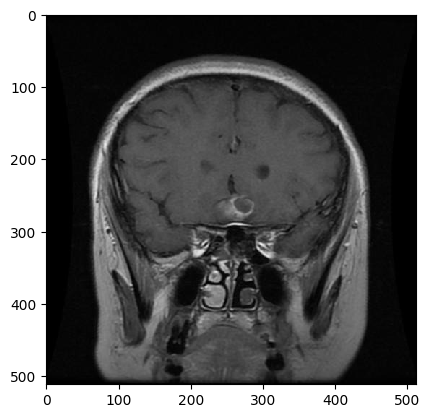

In [74]:
from tensorflow.keras.preprocessing import image
img = image.load_img('../input/brain-tumor-classification-mri/Training/pituitary_tumor/p (107).jpg')
plt.imshow(img,interpolation='nearest')
plt.show()

In [75]:
a=model.predict(img_array)
indices = a.argmax()
indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step


3

In [76]:
model.save('braintumor_20nov2025_retry.keras')

print("Model saved successfully.")

Model saved successfully.
